In [25]:
# cell1
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import platform
from tqdm import tqdm

# 只设置字体，不设置任何随机种子
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

device = torch.device('cpu')
print(f"✅ 系统: {platform.system()}")
print(f"✅ 无固定种子，确保随机性")



✅ 系统: Darwin
✅ 无固定种子，确保随机性


In [26]:
# cell2
df = pd.read_csv('simulated_icf_clinical_data.csv')

def create_sequences(df, n_history=3):
    sequences, targets, patient_ids = [], [], []
    for pid, group in df.groupby('patient_id'):
        group = group.sort_values('time_step')
        features = group[['icf_total', 'rom', 'vas']].values
        for i in range(len(features) - n_history):
            sequences.append(features[i:i+n_history])
            targets.append(features[i+n_history, 0])
            patient_ids.append(pid)
    return np.array(sequences), np.array(targets), patient_ids

X, y, pids = create_sequences(df, n_history=3)
print(f"数据: X{X.shape}, y{y.shape}")

# 无random_state！
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"训练: {len(X_train)}, 测试: {len(X_test)}")

数据: X(150, 3, 3), y(150,)
训练: 120, 测试: 30


In [27]:
# cell3 
# ==================== 特征标准化（重要！） ====================
# 注意：标准化要在划分后进行，避免数据泄漏

# 重塑为2D进行标准化，再恢复为3D
scaler = StandardScaler()

# 训练集标准化
shape_train = X_train.shape
X_train_2d = X_train.reshape(-1, X_train.shape[-1])  # (样本数*步长, 特征数)
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_train = X_train_2d_scaled.reshape(shape_train)

# 测试集用同样的scaler（只能用transform，不能用fit_transform）
X_test_2d = X_test.reshape(-1, X_test.shape[-1])
X_test_2d_scaled = scaler.transform(X_test_2d)
X_test = X_test_2d_scaled.reshape(X_test.shape)

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # 增加维度
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f"数据标准化完成！")
print(f"训练集X范围: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"训练集y范围: [{y_train.min():.2f}, {y_train.max():.2f}]")

# 在Cell 3末尾添加
print("\n标准化后数据范围检查：")
print(f"X_train ICF列: [{X_train[:,:,0].min():.3f}, {X_train[:,:,0].max():.3f}]")
print(f"y_train: [{y_train.min():.3f}, {y_train.max():.3f}]")

数据标准化完成！
训练集X范围: [-2.29, 2.23]
训练集y范围: [112.00, 200.00]

标准化后数据范围检查：
X_train ICF列: [-1.864, 1.555]
y_train: [112.000, 200.000]


In [28]:
# ==================== Transformer预测模型 ====================

class ICFPredictorTransformer(nn.Module):
    def __init__(self, input_size=3, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.d_model = d_model  # 保存为实例变量（可选）
        
        # 把3维特征映射到d_model维
        self.embedding = nn.Linear(input_size, d_model)
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # 输出层
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x: (batch, seq_len=3, input_size=3)
        x = self.embedding(x)  # → (batch, seq_len, d_model)
        d_model = x.size(2)    # 获取实际的特征维度
        
        # 添加位置编码
        positions = torch.arange(x.size(1)).unsqueeze(0).to(x.device)
        pos_encoding = torch.zeros_like(x)
        
        for i in range(0, d_model, 2):
            pos_encoding[:, :, i] = torch.sin(positions / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                pos_encoding[:, :, i+1] = torch.cos(positions / (10000 ** (i / d_model)))
        
        x = x + pos_encoding
        
        # Transformer编码
        x = self.transformer(x)
        
        # 取最后一个时间步
        return self.fc(x[:, -1, :])

# 实例化模型
model = ICFPredictorTransformer(input_size=3, d_model=64, nhead=4, num_layers=2).to(device)
print(f"模型结构:\n{model}")
print(f"\n总参数数量: {sum(p.numel() for p in model.parameters()):,}")

模型结构:
ICFPredictorTransformer(
  (embedding): Linear(in_features=3, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

总参数数量: 562,625


开始训练transformer模型...


 12%|█████████▊                                                                        | 24/200 [00:00<00:04, 43.17it/s]

轮次 [20/200], 平均损失MSE: 19120.1016


 22%|██████████████████                                                                | 44/200 [00:01<00:03, 43.65it/s]

轮次 [40/200], 平均损失MSE: 12370.8450


...

轮次 [160/200], 平均损失MSE: 122.8767


 92%|██████████████████████████████████████████████████████████████████████████▌      | 184/200 [00:04<00:00, 44.10it/s]

轮次 [180/200], 平均损失MSE: 59.1440


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 43.22it/s]

轮次 [200/200], 平均损失MSE: 34.3259

✅ 训练完成！


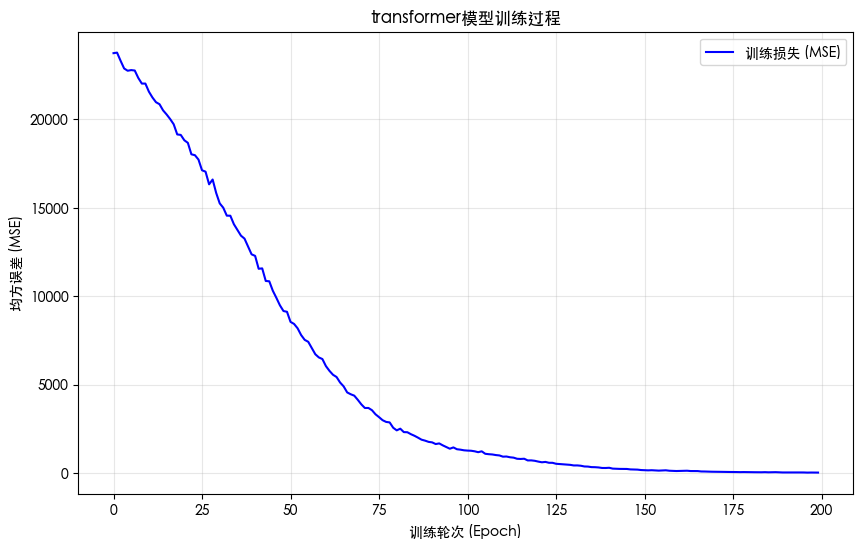


📊 训练效果检查：
最终训练损失: 34.3259
初期训练损失: 23741.3047
损失下降幅度: 99.9%


In [29]:
#cell 5:
# ==================== 模型训练 ====================

# 创建数据加载器（小批量训练）
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差（回归任务）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练循环
num_epochs = 200
train_losses = []

print("开始训练transformer模型...")
for epoch in tqdm(range(num_epochs)):
    model.train()  # 训练模式
    epoch_losses = []
    
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    # 记录平均损失
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    
    # 每20轮打印一次
    if (epoch + 1) % 20 == 0:
        print(f'轮次 [{epoch+1}/{num_epochs}], 平均损失MSE: {avg_loss:.4f}')

print("\n✅ 训练完成！")

# 绘制训练损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='训练损失 (MSE)', color='blue')
plt.xlabel('训练轮次 (Epoch)')
plt.ylabel('均方误差 (MSE)')
plt.title('transformer模型训练过程')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 在Cell 5最后添加
print("\n📊 训练效果检查：")
print(f"最终训练损失: {train_losses[-1]:.4f}")
print(f"初期训练损失: {train_losses[0]:.4f}")
print(f"损失下降幅度: {(train_losses[0] - train_losses[-1])/train_losses[0]*100:.1f}%")

# 如果下降幅度<5%，说明模型没学好
if (train_losses[0] - train_losses[-1])/train_losses[0] < 0.05:
    print("⚠️ 警告：损失下降不明显，模型可能欠拟合！")
    print("建议增加训练轮数或调整学习率")

📊 模型性能评估：
训练集 MSE: 28.4207
测试集 MSE: 99.3735
测试集 RMSE: 9.9686
测试集平均绝对误差: 8.2043
r2= 0.8347997126987281
✅ 散点图已保存为 scatter_plot.png
✅ 随机选中患者: ['P041', 'P019', 'P032']
✅ 轨迹图已保存: trajectory_P041.png
✅ 轨迹图已保存: trajectory_P019.png
✅ 轨迹图已保存: trajectory_P032.png

✅ 所有评估完成！模型已保存为 'icf_transformer_model.pth'
正在生成要求的 icf_prediction_results.png...
✅ 已生成 demo_output/icf_prediction_results.png

预览生成的图片：


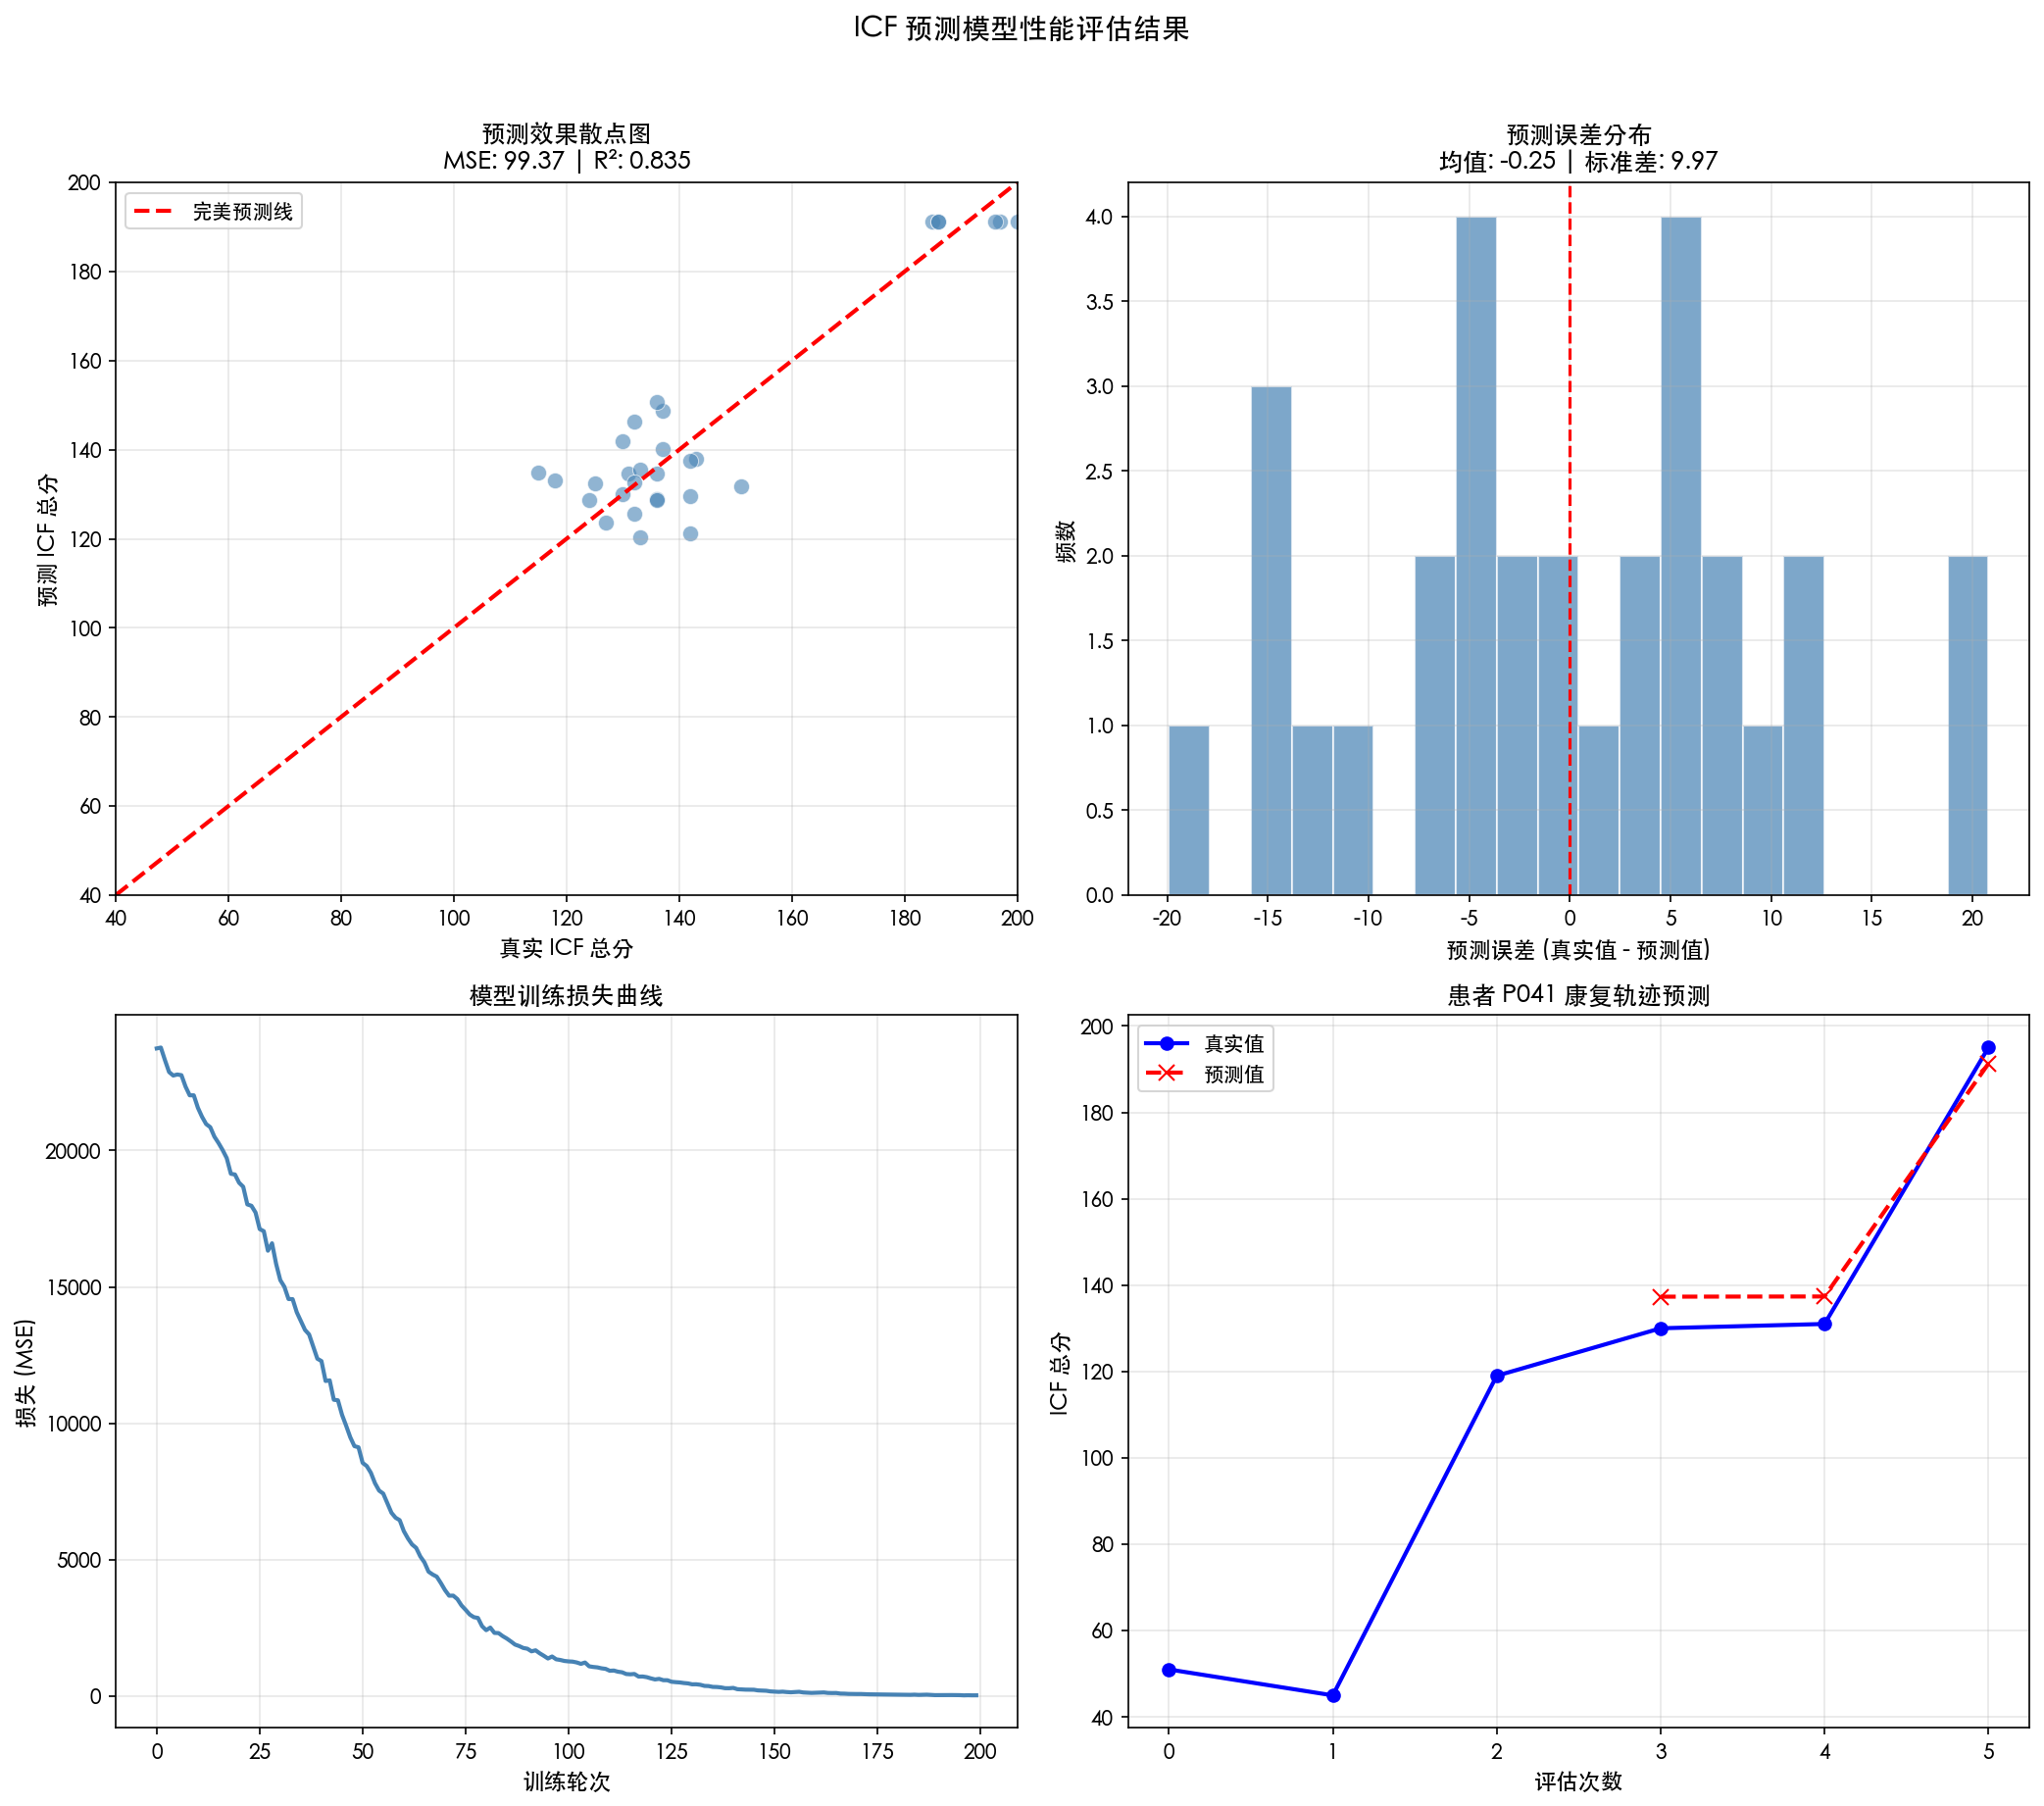

In [30]:
#cell 6:
import os
os.environ['MPLBACKEND'] = 'Agg'  # 完全禁用任何显示

%matplotlib inline
# ==================== 模型评估 ====================
# 预测
model.eval()  # 评估模式
with torch.no_grad():
    y_pred_train = model(X_train_tensor).cpu().numpy()
    y_pred_test = model(X_test_tensor).cpu().numpy()

# 计算MSE和RMSE
mse_train = np.mean((y_train - y_pred_train.flatten())**2)
mse_test = np.mean((y_test - y_pred_test.flatten())**2)
rmse_test = np.sqrt(mse_test)

print(f"📊 模型性能评估：")
print(f"训练集 MSE: {mse_train:.4f}")
print(f"测试集 MSE: {mse_test:.4f}")
print(f"测试集 RMSE: {rmse_test:.4f}")
print(f"测试集平均绝对误差: {np.mean(np.abs(y_test - y_pred_test.flatten())):.4f}")

# ==================== 可视化1：预测值 vs 真实值 ====================
# 保存散点图（不显示）
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=50)
plt.plot([40, 200], [40, 200], 'r--', lw=2,label='完美预测线')
plt.title(f'测试集预测效果\nMSE: {mse_test:.4f} | RMSE: {rmse_test:.4f}', fontsize=14)
plt.xlabel('真实ICF总分', fontsize=12)
plt.ylabel('预测ICF总分', fontsize=12)

# 添加R²分数
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
print("r2=",r2)

plt.savefig('scatter_plot.png', dpi=100)
plt.close()  # 必须关闭，否则会内存泄漏
print("✅ 散点图已保存为 scatter_plot.png")


# ==================== 可视化2：时序预测对比（选3个患者） ====================
import random

# 从所有患者中随机选3个（不依赖测试集划分）
all_pids = df['patient_id'].unique().tolist()
random.shuffle(all_pids)
test_pids = all_pids[:3]
print(f"✅ 随机选中患者: {test_pids}")

plt.figure(figsize=(15, 10))
for idx, pid in enumerate(test_pids):
    # 找到该患者的所有数据
    patient_df = df[df['patient_id'] == pid].sort_values('time_step')
    
    # 生成该患者的预测序列（需要重新跑一遍create_sequences逻辑）
    features = patient_df[['icf_total', 'rom', 'vas']].values
    true_icf = patient_df['icf_total'].values
    time_steps = patient_df['time_step'].values
    
    # 用训练好的模型预测（如果有足够历史数据）
    predictions = []
    pred_times = []
    
    for i in range(3, len(features)):  # 从第4个时间点开始预测（需要前3个）
        hist = features[i-3:i]
        hist_scaled = scaler.transform(hist.reshape(-1, 3)).reshape(1, 3, 3)
        hist_tensor = torch.FloatTensor(hist_scaled).to(device)
        
        with torch.no_grad():
            pred = model(hist_tensor).cpu().numpy()[0][0]
        predictions.append(pred)
        pred_times.append(time_steps[i])
    
    # 绘图
    plt.subplot(3, 1, idx+1)
    plt.plot(time_steps, true_icf, 'bo-', label='真实ICF', markersize=8, linewidth=2)
    if predictions:
        plt.plot(pred_times, predictions, 'rx--', label='预测ICF', markersize=8, linewidth=2)
    plt.xlabel('Time Step (评估次数)', fontsize=10)
    plt.ylabel('ICF总分', fontsize=10)
    plt.title(f'患者 {pid} 康复轨迹预测', fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(40, 200)  # 固定Y轴范围
    plt.xticks(time_steps)
    plt.savefig(f'trajectory_{pid}.png', dpi=100)
    plt.close()
    print(f"✅ 轨迹图已保存: trajectory_{pid}.png")


print("\n✅ 所有评估完成！模型已保存为 'icf_transformer_model.pth'")
torch.save(model.state_dict(), 'icf_transformer_model.pth')

# ==================== 生成要求的预测结果图 ====================
print("正在生成要求的 icf_prediction_results.png...")

# 使用训练好的模型进行预测并可视化
model.eval()
with torch.no_grad():
    y_pred_all = model(X_test_tensor).cpu().numpy()

# 创建预测结果图
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 图1：预测值 vs 真实值散点图
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_all, alpha=0.6, s=60, c='steelblue', edgecolors='white', linewidth=0.5)
ax1.plot([40, 200], [40, 200], 'r--', lw=2, label='完美预测线')
ax1.set_xlabel('真实 ICF 总分', fontsize=11)
ax1.set_ylabel('预测 ICF 总分', fontsize=11)
ax1.set_title(f'预测效果散点图\nMSE: {mse_test:.2f} | R²: {r2:.3f}', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(40, 200)
ax1.set_ylim(40, 200)

# 图2：残差分布
ax2 = axes[0, 1]
residuals = y_test - y_pred_all.flatten()
ax2.hist(residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
ax2.set_xlabel('预测误差 (真实值 - 预测值)', fontsize=11)
ax2.set_ylabel('频数', fontsize=11)
ax2.set_title(f'预测误差分布\n均值: {residuals.mean():.2f} | 标准差: {residuals.std():.2f}', fontsize=12)
ax2.grid(True, alpha=0.3)

# 图3：训练损失曲线
ax3 = axes[1, 0]
ax3.plot(train_losses, color='steelblue', linewidth=2)
ax3.set_xlabel('训练轮次', fontsize=11)
ax3.set_ylabel('损失 (MSE)', fontsize=11)
ax3.set_title('模型训练损失曲线', fontsize=12)
ax3.grid(True, alpha=0.3)

# 图4：选一个患者的预测轨迹示例
ax4 = axes[1, 1]
# 选一个测试集的患者
sample_pid = test_pids[0]
patient_df = df[df['patient_id'] == sample_pid].sort_values('time_step')
features = patient_df[['icf_total', 'rom', 'vas']].values
true_icf = patient_df['icf_total'].values
time_steps = patient_df['time_step'].values

# 预测
predictions = []
pred_times = []
for i in range(3, len(features)):
    hist = features[i-3:i]
    hist_scaled = scaler.transform(hist.reshape(-1, 3)).reshape(1, 3, 3)
    hist_tensor = torch.FloatTensor(hist_scaled).to(device)
    with torch.no_grad():
        pred = model(hist_tensor).cpu().numpy()[0][0]
    predictions.append(pred)
    pred_times.append(time_steps[i])

ax4.plot(time_steps, true_icf, 'bo-', label='真实值', markersize=6, linewidth=2)
if predictions:
    ax4.plot(pred_times, predictions, 'rx--', label='预测值', markersize=8, linewidth=2)
ax4.set_xlabel('评估次数', fontsize=11)
ax4.set_ylabel('ICF 总分', fontsize=11)
ax4.set_title(f'患者 {sample_pid} 康复轨迹预测', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('ICF 预测模型性能评估结果', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('demo_output/icf_prediction_results.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 已生成 demo_output/icf_prediction_results.png")

# 显示图片（在notebook中）
from IPython.display import Image, display
print("\n预览生成的图片：")
display(Image('demo_output/icf_prediction_results.png'))